Data exploration decisions

This notebook explores factors that are most associated with used-car price and produces charts and summary insights for reporting.

Primary tasks covered:
- identify key variables affecting `price_usd`
- run correlation analysis on numeric features
- generate clear visualizations for interpretation

The notebook prefers the engineered dataset when available and falls back to the cleaned dataset if needed.

In [1]:
# Run this once in fresh notebook environments where required packages are missing.
%pip install pandas numpy matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CANDIDATES = [
    Path("../data/feature_engineered_used_cars.csv"),
    Path("feature_engineered_used_cars.csv"),
    Path("../data/cleaned_used_cars.csv"),
    Path("cleaned_used_cars.csv"),
]

## 1. Load the analysis dataset

We load the best available dataset for exploration. If engineered features already exist, they are used first so correlation and variable-impact analysis can include those fields.

In [2]:
def resolve_existing_path(candidates):
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "No expected input dataset was found in: " + ", ".join(str(p) for p in candidates)
    )

input_path = resolve_existing_path(INPUT_CANDIDATES)
df = pd.read_csv(input_path)

print(f"Using input file: {input_path.resolve()}")
print(f"Rows, columns: {df.shape}")
display(df.head())

Using input file: /workspaces/COMP-3250-Used-Car-Price-Estimation/data/feature_engineered_used_cars.csv
Rows, columns: (4009, 20)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,price_usd,mileage_mi,clean_title_flag,accident_reported,model_year_numeric,car_age,scaled_mileage,fuel_type_encoded
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300",10300,51000,True,True,2013,13.0,51.000,NaN
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005",38005,34742,True,True,2021,5.0,34.742,0.0
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598",54598,22372,NaN,False,2022,4.0,22.372,0.0
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,"$15,500",15500,88900,True,False,2015,11.0,88.900,NaN
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999",34999,9835,NaN,False,2021,5.0,9.835,0.0


## 2. Prepare the target variable and numeric features

To ensure a consistent analysis, we confirm that `price_usd` exists as numeric. Then we build a numeric-only view of the data for correlation and key-variable ranking.

In [3]:
if "price_usd" not in df.columns:
    if "price" in df.columns:
        df["price_usd"] = pd.to_numeric(
            df["price"].astype(str).str.replace(r"[\$,]", "", regex=True),
            errors="coerce",
        )
    else:
        raise KeyError("Neither 'price_usd' nor raw 'price' column was found.")

numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.dropna(axis=0, how="any")

print("Numeric columns used in exploration:")
print(list(numeric_df.columns))
print(f"Rows kept for complete-case numeric analysis: {len(numeric_df)}")

Numeric columns used in exploration:
['model_year', 'price_usd', 'mileage_mi', 'model_year_numeric', 'car_age', 'scaled_mileage', 'fuel_type_encoded']
Rows kept for complete-case numeric analysis: 3425


## 3. Correlation analysis

We compute Pearson correlations among numeric variables and rank features by the absolute correlation with `price_usd`. This helps identify variables that are most linearly associated with price.

In [8]:
corr_matrix = numeric_df.corr(numeric_only=True)

price_corr = (
    corr_matrix["price_usd"]
    .drop(labels=["price_usd"], errors="ignore")
    .dropna()
    .sort_values(key=np.abs, ascending=False)
    .rename("corr_with_price_usd")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(corr_matrix.round(3))
display(price_corr.head(12))

,model_year,price_usd,mileage_mi,model_year_numeric,car_age,scaled_mileage,fuel_type_encoded
model_year,1.000,0.190,-0.609,1.000,-1.000,-0.609,0.011
price_usd,0.190,1.000,-0.296,0.190,-0.190,-0.296,0.009
mileage_mi,-0.609,-0.296,1.000,-0.609,0.609,1.000,0.096
model_year_numeric,1.000,0.190,-0.609,1.000,-1.000,-0.609,0.011
car_age,-1.000,-0.190,0.609,-1.000,1.000,0.609,-0.011
scaled_mileage,-0.609,-0.296,1.000,-0.609,0.609,1.000,0.096
fuel_type_encoded,0.011,0.009,0.096,0.011,-0.011,0.096,1.000


,feature,corr_with_price_usd
0,scaled_mileage,-0.296403
1,mileage_mi,-0.296403
2,car_age,-0.190089
3,model_year_numeric,0.190089
4,model_year,0.190089
5,fuel_type_encoded,0.008979


## 4. Data visualization (priority charts)

This section focuses on the four primary charts for the report in priority order:

1. Price vs Mileage (scatter)
2. Price vs Car Age (scatter)
3. Price Distribution (histogram)
4. Correlation Heatmap

These visuals are saved to the results folder so they can be reused directly in slides or the final report.

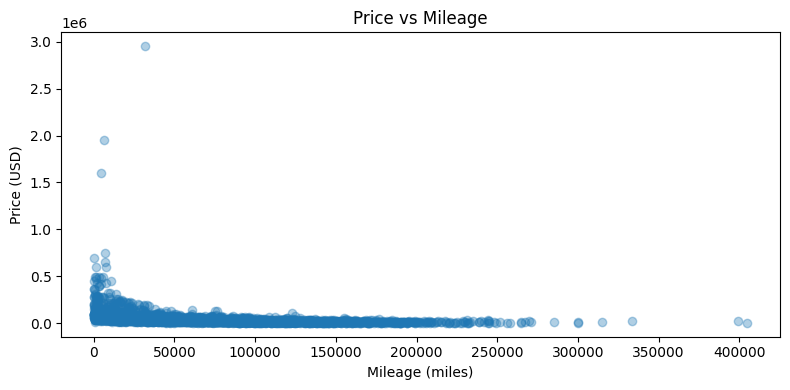

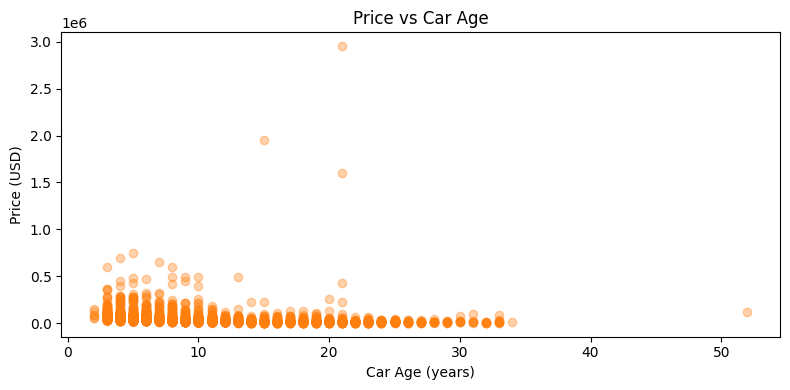

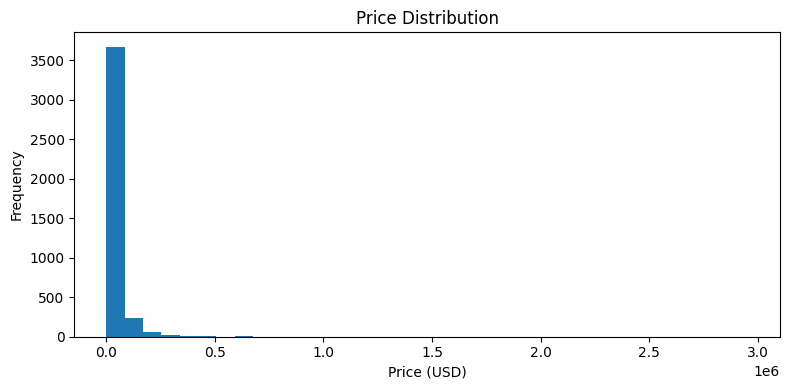

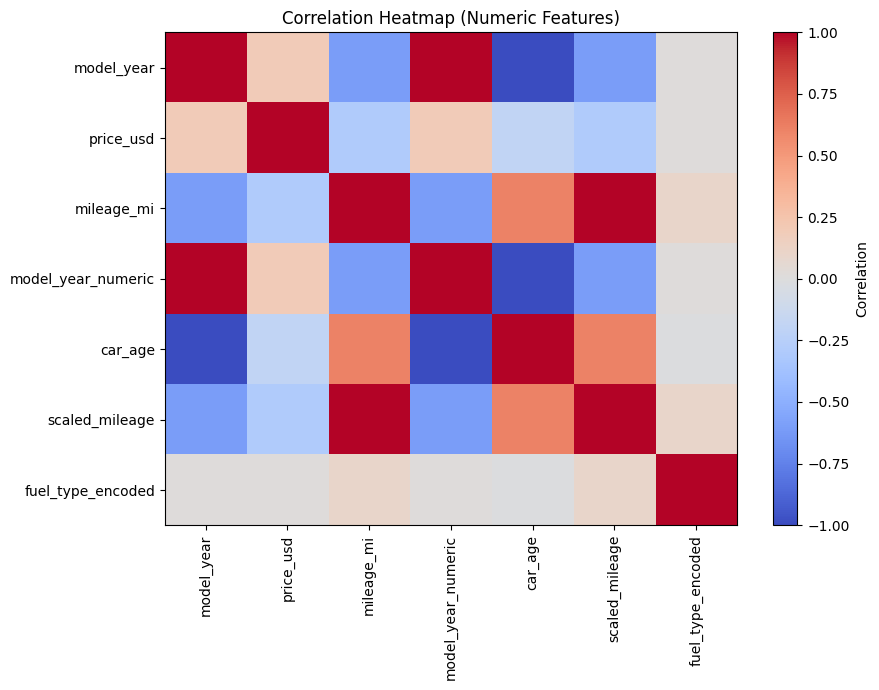

In [9]:
# Graph 1: Price vs Mileage (MUST HAVE)
mileage_plot_col = None
if "mileage_mi" in df.columns:
    mileage_plot_col = "mileage_mi"
elif "scaled_mileage" in df.columns:
    # Convert back to miles if only scaled mileage is available.
    df["mileage_mi_from_scaled"] = df["scaled_mileage"] * 1000
    mileage_plot_col = "mileage_mi_from_scaled"

if mileage_plot_col is not None:
    plot_df = df[[mileage_plot_col, "price_usd"]].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(plot_df[mileage_plot_col], plot_df["price_usd"], alpha=0.35)
    ax.set_title("Price vs Mileage")
    ax.set_xlabel("Mileage (miles)")
    ax.set_ylabel("Price (USD)")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "eda_price_vs_mileage.png", dpi=150)
    plt.show()

# Graph 2: Price vs Car Age
if "car_age" in df.columns:
    plot_df = df[["car_age", "price_usd"]].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(plot_df["car_age"], plot_df["price_usd"], alpha=0.35, color="tab:orange")
    ax.set_title("Price vs Car Age")
    ax.set_xlabel("Car Age (years)")
    ax.set_ylabel("Price (USD)")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "eda_price_vs_car_age.png", dpi=150)
    plt.show()

# Graph 3: Price Distribution (Histogram)
fig, ax = plt.subplots(figsize=(8, 4))
df["price_usd"].dropna().plot(kind="hist", bins=35, ax=ax)
ax.set_title("Price Distribution")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "eda_price_distribution.png", dpi=150)
plt.show()

# Graph 4: Correlation Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation Heatmap (Numeric Features)")
fig.colorbar(im, ax=ax, label="Correlation")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "eda_correlation_heatmap.png", dpi=150)
plt.show()

## 5. Key variables affecting price

This table highlights variables with the strongest linear relationship to `price_usd` based on absolute correlation magnitude.

In [6]:
key_variables = price_corr.copy()
key_variables["abs_corr"] = key_variables["corr_with_price_usd"].abs()
key_variables = key_variables.sort_values("abs_corr", ascending=False)

display(key_variables.head(10))

key_variables.head(10).to_csv(
    RESULTS_DIR / "eda_key_variables_by_correlation.csv", index=False
)
print("Saved key variable ranking to results/eda_key_variables_by_correlation.csv")

,feature,corr_with_price_usd,abs_corr
0,scaled_mileage,-0.296403,0.296403
1,mileage_mi,-0.296403,0.296403
2,car_age,-0.190089,0.190089
3,model_year_numeric,0.190089,0.190089
4,model_year,0.190089,0.190089
5,fuel_type_encoded,0.008979,0.008979


Saved key variable ranking to results/eda_key_variables_by_correlation.csv


## 6. Insights for report

The statements below are generated from the analysis outputs and can be copied directly into the report narrative.

In [10]:
top_feature = key_variables.iloc[0] if not key_variables.empty else None
median_price = df["price_usd"].median()

insights = []
insights.append(f"Median used-car price is ${median_price:,.0f}.")

if top_feature is not None:
    direction = "positive" if top_feature["corr_with_price_usd"] > 0 else "negative"
    insights.append(
        f"The strongest linear relationship with price is {top_feature['feature']} "
        f"(correlation = {top_feature['corr_with_price_usd']:.3f}, {direction})."
    )

if "car_age" in df.columns:
    age_corr = key_variables.loc[
        key_variables["feature"].eq("car_age"), "corr_with_price_usd"
    ]
    if not age_corr.empty:
        direction = "decreases" if age_corr.iloc[0] < 0 else "increases"
        insights.append(
            f"As car age rises, price generally {direction} "
            f"(car_age correlation = {age_corr.iloc[0]:.3f})."
        )

if "scaled_mileage" in df.columns or "mileage_mi" in df.columns:
    mileage_feature = "scaled_mileage" if "scaled_mileage" in key_variables["feature"].values else "mileage_mi"
    mileage_corr = key_variables.loc[
        key_variables["feature"].eq(mileage_feature), "corr_with_price_usd"
    ]
    if not mileage_corr.empty:
        direction = "decreases" if mileage_corr.iloc[0] < 0 else "increases"
        insights.append(
            f"Higher mileage generally corresponds to lower price "
            f"({mileage_feature} correlation = {mileage_corr.iloc[0]:.3f}; price {direction} with mileage)."
        )

print("Report-ready insights:")
for i, text in enumerate(insights, start=1):
    print(f"{i}. {text}")

insights_df = pd.DataFrame({"insight": insights})
insights_df.to_csv(RESULTS_DIR / "eda_report_insights.csv", index=False)
print("Saved insights to results/eda_report_insights.csv")

Report-ready insights:
1. Median used-car price is $31,000.
2. The strongest linear relationship with price is scaled_mileage (correlation = -0.296, negative).
3. As car age rises, price generally decreases (car_age correlation = -0.190).
4. Higher mileage generally corresponds to lower price (scaled_mileage correlation = -0.296; price decreases with mileage).
Saved insights to results/eda_report_insights.csv
